# A complete Guide to End-to-End Machine Learning Project.
* In this Notebook, we are going to Build an End-to-End Machine Learning Project.
* This notebook will help you how to think while working on End-to-End machine Leanring Project.
* This Notebook will help you to Analyze details from business point of view rather then just modeling.
* Let's say you are working as a data scientist in Real Estate Company.
* Main steps we will go through

# Overviews
**1. Look at the big picture.<br>
2. Get the data.<br>
3. Discover and visualize the data to gain insights.<br>
4. Prepare the data for Machine Learning algorithms.<br>
5. Select a model and train it.<br>
6. Fine-tune your model.<br>
7. Test your model on Test Dataset.**

## 1. Look at the Big Picture

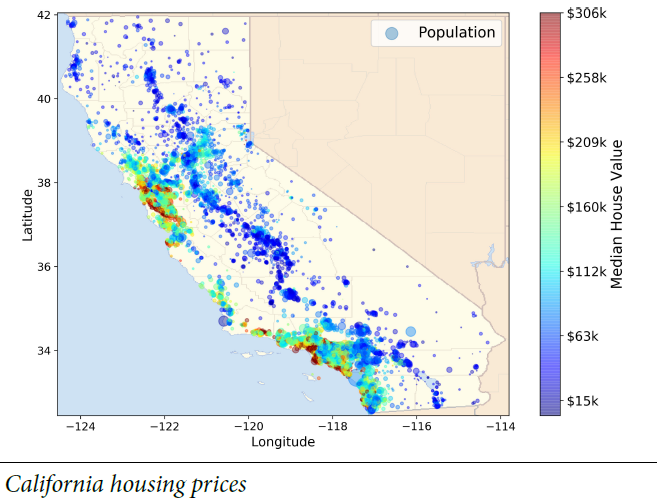

## TASK: As a Data scientist your task is to build a model of housing prices in California using the California census data.

* This data has metrics such as the population, median income, median housing price, and so on for each block group in California.
* Block groups are the smallest geographical unit for which the US Census Bureau publishes sample data.
* We will just call them “districts” for short.
* Your model should learn from this data and be able to predict the median housing price in any district, given all the other metrics.

# Frame the Problem

* First, ask your Boss. What is the **Business objective** of this Model?. How does the company expect to use and benefit from this model?
* Building the Model is not only your end Goal

* Answering the above questions will help you decide what algorithms you will select, what performance measure you will use to evaluate your model, and how much effort you should spend tweaking it.

* Your boss answers that your model’s output (a prediction of a district’s median housing price) will be fed to another Machine Learning system along with many other signals.
* This downstream system will determine whether it is worth investing in a given area or not. **Getting this right is critical, as it directly affects revenue.**

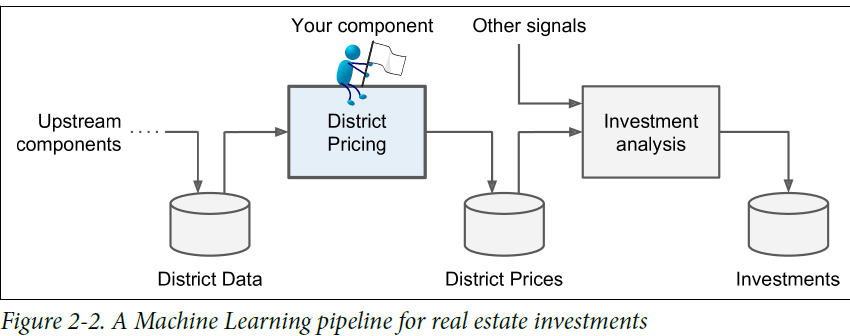

* This task seems to be a Multiple Regression Problem.
* Next, we have to Select a Perfromance Measure.
* A typical performance measure for regression problems is the `Root Mean Square Error (RMSE).`

# 2. Get the Data

In [1]:
# import liraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('C:\\Users\\Ranjan Singh\\OneDrive\\Desktop\\ML_PROJECTS\\california-housing-prices.csv\\housing.csv')

Let's look into the data

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Inference:
1. There are total 20,640 instances in the dataset. <br>
2. `total_bedrooms` attribute has only 20,433 null values, meaning that 207 districts are missing in this feature.<br>
3. All attributes/columns are numerical, except the `ocean_proximity`.

In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


* Another quick way to get a feel of the type of data you are dealing with is to plot a histogram for each numerical attribute/columns.
* You can call the hist() method on the whole dataset, and it will plot a histogram for each numerical attribute.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

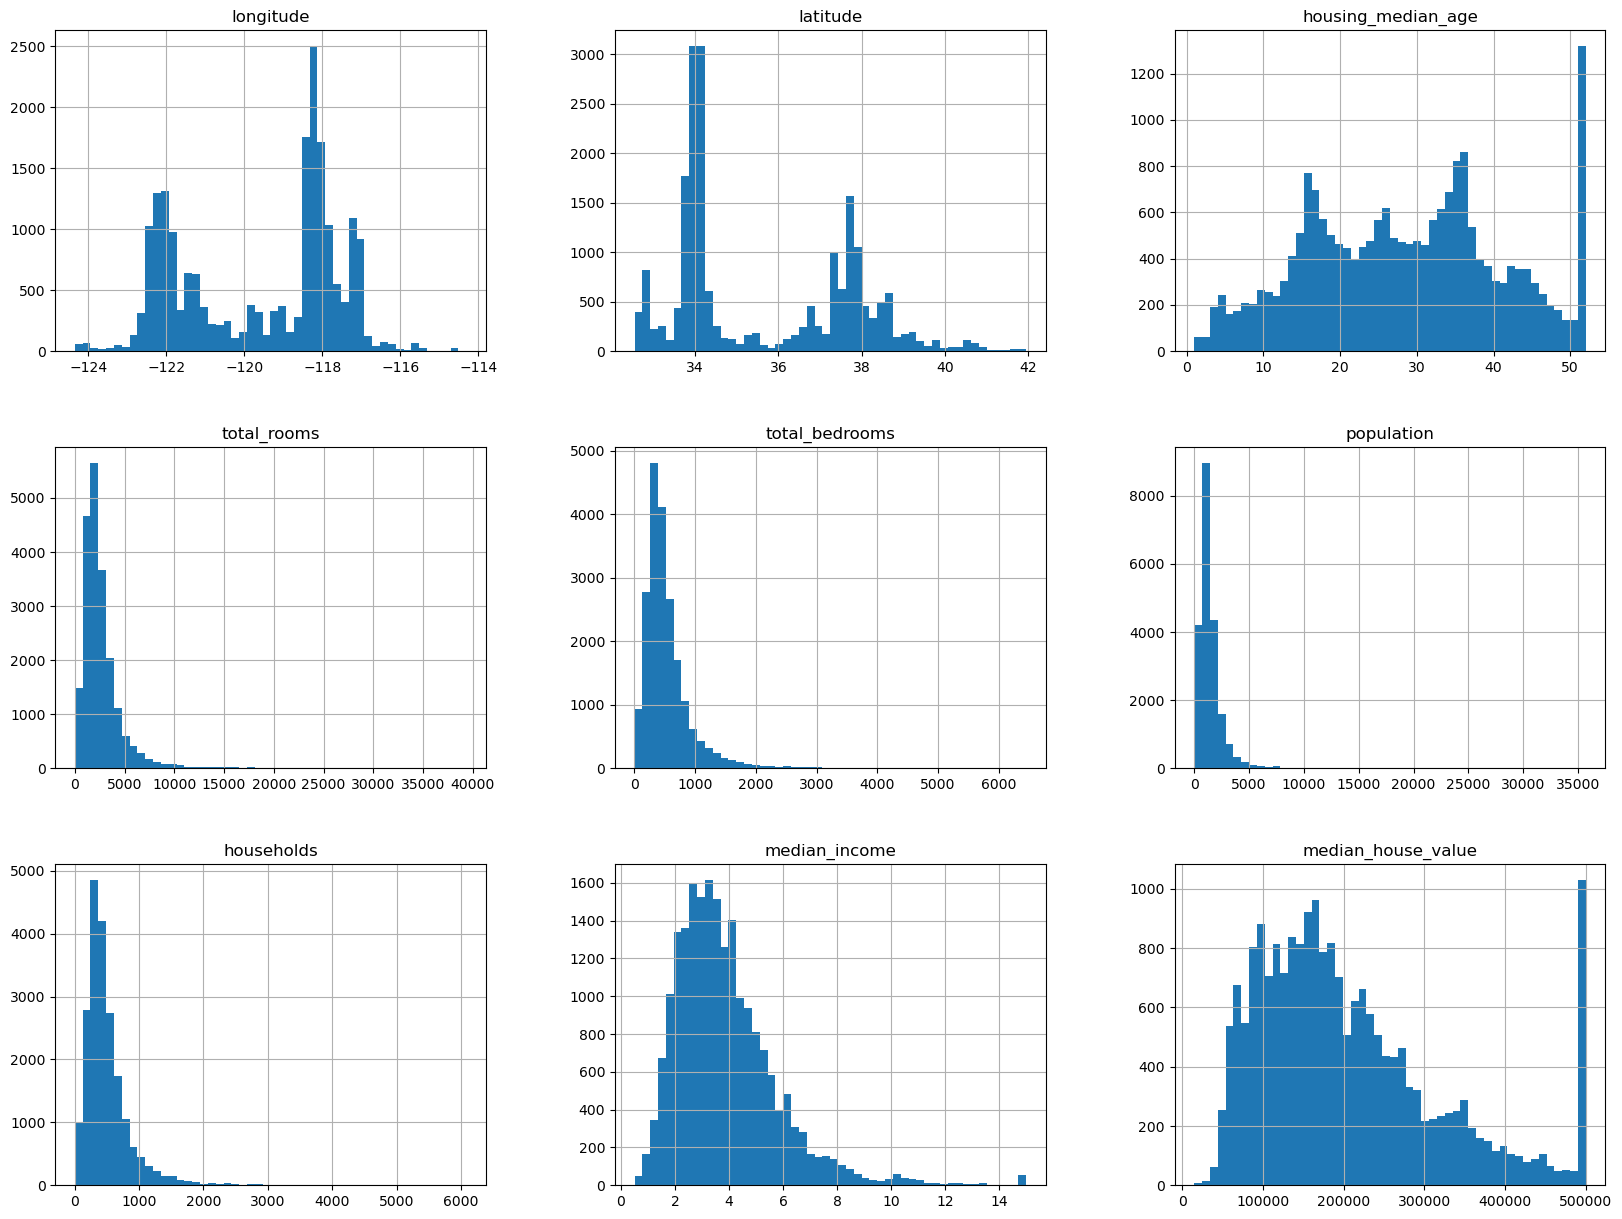

In [8]:
df.hist(bins=50, figsize=(20,15))

### Inference made from these histograms

1. First, the `median income` attribute does not look like it is expressed in `US dollars (USD)`. After checking with the team that collected the data, you are told that the data has been scaled and capped at 15 (actually 15.0001) for higher median incomes, and at 0.5 (actually 0.4999) for lower median incomes. The numbers represent roughly tens of thousands of dollars (e.g., 3 actually means about $30,000).
  * Working with preprocessed attributes is common in Machine Learning, Get the Data and it is not necessarily a problem, **but you should try to understand how the data was computed.**

2. The `housing median age` and the `median house value` were also capped. The later may be a serious problem since it is your target attribute (your labels). Your Machine Learning algorithms may learn that prices never go beyond that limit. You need to check with your client team (the team that will use your system’s output) to see if this is a problem or not. If they tell you that they need precise predictions even beyond  
$500,000, then you have mainly two options: <br>
> a.  Collect proper labels for the districts whose labels were capped.<br>
> b.  Remove those districts from the training set (and also from the test set, since your system should not be evaluated poorly if it predicts values beyond $500,000).


3. These attributes have very different scales. We will discuss this later in this notebook when we explore **feature scaling.**

4. Finally, many histograms are `tail heavy`: they extend much farther to the right of the median than to the left. This may make it a bit harder for some Machine Learning algorithms to detect patterns. We will try transforming these attributes later on to have more bell-shaped distributions.

**NOTE: Before doing anything with data. Let's create a test set and never look at it to avoid bais.**

In [9]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=None)

### Points to consider while doing train_test_split

- So far we have considered purely random sampling methods. This is generally fine if your dataset is large enough (especially relative to the number of attributes), but if it is not, you run the risk of introducing a significant sampling bias.
- When a survey company decides to call 1,000 people to ask them a few questions, they don’t just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people are representative of the whole population.
- For example, the US population is composed of 51.3% female and 48.7% male, so a well-conducted survey in the US would try to maintain this ratio in the sample: 513 female and 487 male. **This is called stratified sampling: the population is divided into homogeneous subgroups called strata, and the right number of instances is sampled from each stratum to guarantee that the test set is representative of the overall population.**

#### Business insights
- Suppose you chatted with experts who told you that the median income is a very important attribute to predict median housing prices.
- You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset.
- Since the median income is a continuous numerical attribute, you first need to create an income category attribute.
- Let’s look at the median income histogram more closely (back in Figure of histograms): most median income values are clustered around 1.5 to 6 (i.e., 15,000– 60,000), but some median incomes go far beyond 6.
- It is important to have a sufficient number of instances in your dataset for each stratum, or else the estimate of the stratum’s importance may be biased. This means that you should not have too many strata, and each stratum should be large enough.
- The following code uses the pd.cut() function to create an income category attribute with 5 categories (labeled from 1 to 5): category 1 ranges from 0 to 1.5 (i.e., less than $15,000), category 2 from 1.5 to 3, and so on:

In [10]:
# Bin values into discrete intervals.
df["income_cat"] = pd.cut(df["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]) #cut the median income across bins and give labels to each bin

<Axes: >

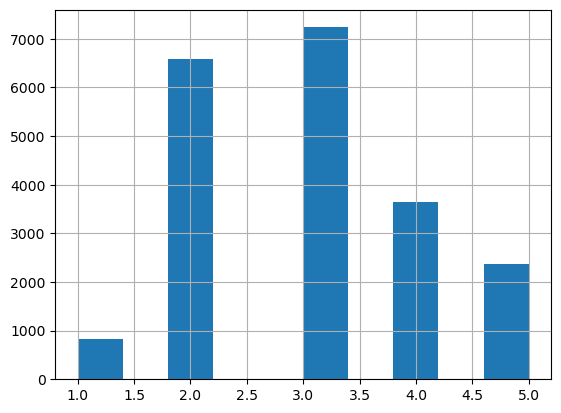

In [11]:
df["income_cat"].hist()

Now, Let's do `stratified sampling` based on the income category. For this you can use `Scikit-Learn’s StratifiedShuffleSplit` class:

In [12]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # Provides train/test indices to split data in train/test sets.
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [13]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [14]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

You can see the proportion of each class is same in train and test set and it is also same in df(you can check).

* Now you should remove the income_cat attribute so the data is back to its original state:

In [15]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

* We spent quite a bit of time on test set generation for a good reason: this is an often neglected but critical part of a Machine Learning project.
* Moreover, many of these ideas will be useful later when we discuss cross-validation.
* Now it’s time to move on to the next stage: exploring the data.

**Discover and Visualize the Data to Gain Insights**

In [16]:
# Let’s create a copy so you can play with it without harming the training set:

housing = strat_train_set.copy()

Visualizing the Geographical data

<Axes: xlabel='longitude', ylabel='latitude'>

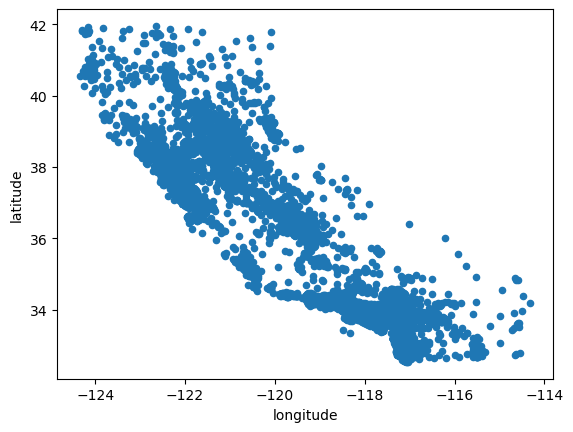

In [17]:
housing.plot(kind="scatter", x="longitude", y="latitude")

Setting the alpha option to 0.1 makes it much easier to visualize the places where there is a high density of data points (Figure 2-12):

<Axes: xlabel='longitude', ylabel='latitude'>

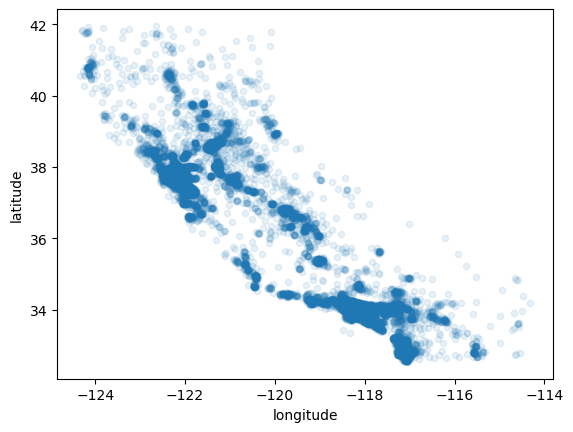

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

### TIP: More generally, our brains are very good at spotting on pictures, but you may need to play around with visualization parameters to make the pattern stand out.

Now let’s look at the housing prices. The radius of each `circle` represents the `district’s population (option s)`, and the color represents the `price (option c)`. We will use a predefined color map (option cmap) called jet, which ranges from blue (low values) to red (high prices):

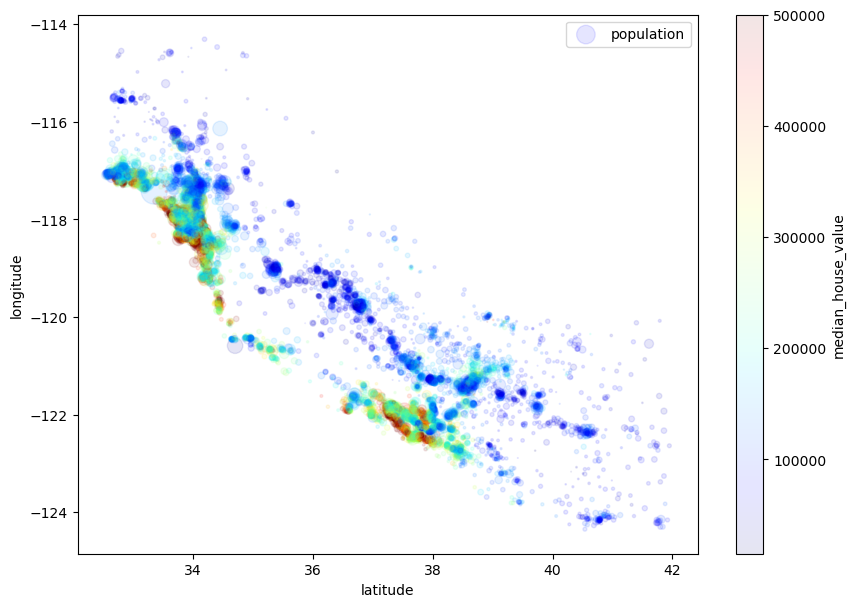

In [19]:
housing.plot(kind="scatter", x="latitude", y="longitude", alpha=0.1, s=housing["population"]/100, label="population", figsize=(10,7), c="median_house_value", cmap=plt.get_cmap("jet"),colorbar=True)
plt.legend()

This image tells you that the housing prices are very much related to the location(e.g., close to the ocean) and to the population density, as you probably knew already.

#### Looking for correlations

In [20]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781
population,0.108071,-0.115290,-0.298737,0.855103,0.876324,1.000000,0.904639,0.002421,-0.026882
households,0.063146,-0.077765,-0.306473,0.918396,0.980167,0.904639,1.000000,0.010869,0.064590
median_income,-0.019615,-0.075146,-0.111315,0.200133,-0.009643,0.002421,0.010869,1.000000,0.687151
median_house_value,-0.047466,-0.142673,0.114146,0.135140,0.047781,-0.026882,0.064590,0.687151,1.000000


<Axes: >

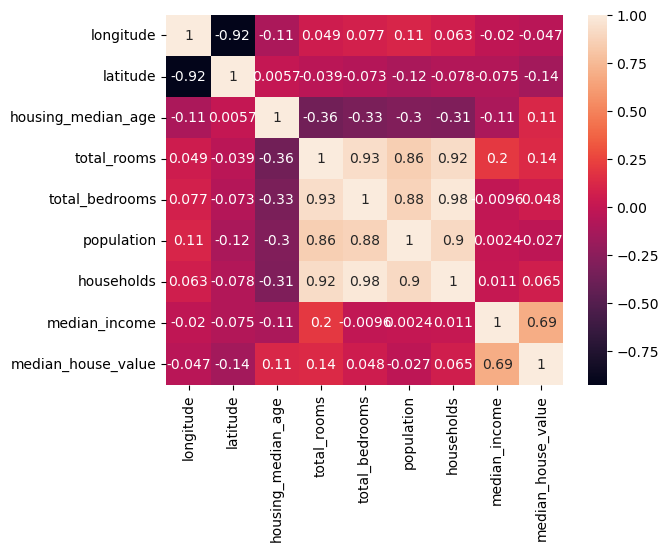

In [21]:
sns.heatmap(corr_matrix, annot=True)

In [22]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

* The **correlation coefficient** ranges from –1 to 1. When it is close to 1, it means that there is a **strong positive correlation**; for example, the median house value tends to go up when the median income goes up.
* When the coefficient is close to –1, it means that there is a **strong negative correlation**; you can see a small negative correlation between the latitude and the median house value (i.e., prices have a slight tendency to go down when you go north).


<Axes: xlabel='median_income', ylabel='median_house_value'>

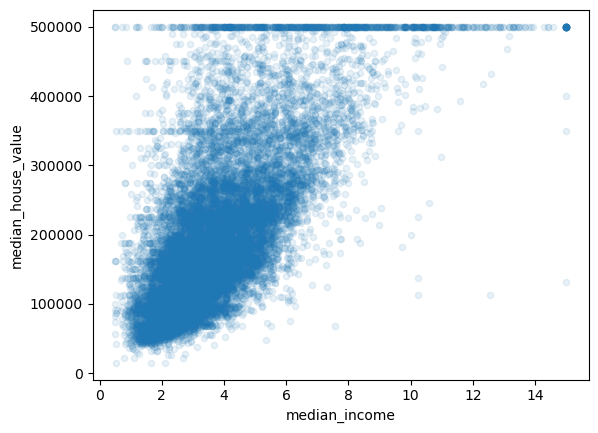

In [23]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

* This plot reveals a few things. First, the correlation is indeed very strong; you can clearly see the upward trend and the points are not too dispersed.
* Second, the price cap that we noticed earlier is clearly visible as a horizontal line at $500,000. But this plot reveals other less obvious straight lines: a horizontal line around $450,000, another around $350,000,perhaps one around $280,000, and a few more below that.
* You may want to try removing the corresponding districts to prevent your algorithms from learning to reproduce these data quirks.

### Experimenting with Attribute Combinations

* One last thing you may want to do before actually preparing the data for Machine Learning algorithms is to try various attribute combinations.
* For example, the total number of rooms in a district is not very useful if you don't know how many households there are.
* What you really want is the number of rooms per household.
* Similarly, the total number of bedrooms by itself is not very useful: you probably want to compare it to the number of rooms.
* And the population per household also seems like an interesting attribute combination to look at. Let’s create these new attributes.

In [24]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


In [25]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

In [26]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,6.096552,0.182692,3.167241
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN,6.658342,0.184696,2.023976
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND,5.571932,0.179977,3.363188
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,4.110465,0.234795,2.662791
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN,6.297405,0.183835,2.411178


Let's look correlation matrix again 

In [27]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

## INFERENCE:

* The new bedrooms_per_room attribute is much more correlated with the median house value than the total number of rooms or bedrooms.
* Apparently houses with a lower bedroom/room ratio tend to be more expensive.
* The number of rooms per household is also more informative than the total number of rooms in a district—obviously the larger the houses, the more expensive they are.

## 4. Prepare the Data for Machine Learning Algorithms

It’s time to prepare the data for your Machine Learning algorithms. Instead of just doing this manually, you should write functions to do that, for several good reasons:

* This will allow you to reproduce these transformations easily on any dataset (e.g., the next time you get a fresh dataset).
* You will gradually build a library of transformation functions that you can reuse in future projects.
* You can use these functions in your live system to transform the new data before feeding it to your algorithms.
* This will make it possible for you to easily try various transformations and see which combination of transformations works best.

In [28]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy() #splitting the predictors and target variable

## Data Cleaning

* First, ML algorithms don’t work with missing features, so let’s create a few functions to take care of them.
* You noticed earlier that the total_bedrooms attribute has some missing values, so let’s fix this. You have three options:
* Get rid of the corresponding districts (Delete all rows that have missing values.)
* Get rid of the whole attribute (remove the entire feature/column from the dataset.)
* Set the values to some value (zero, the mean, the median, etc.)

In [29]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [30]:
housing_num = housing.drop("ocean_proximity", axis=1) # since median can only be calculated on numerical attributes, 
#we need to drop the text attribute ocean_proximity for now. We will deal with it later.

In [31]:
# Now you can fit the imputer instance to the training data using the fit() method, 
# which simply computes the median of each attribute and stores the result in the imputer instance:
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [32]:
imputer.statistics_ # Shows the median/mean/most-frequent values learned from each column, which will be used to replace missing values.

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

Only the total_bedrooms attribute had missing values, but we cannot be sure that there won’t be any missing values in new data after the system goes live, so it is safer to apply the imputer to all the numerical attributes:

In [33]:
housing_num.median().values # Get the median of every numeric column and convert it into a NumPy array for machine learning use.

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

Now you can use this “trained” imputer to transform the training set by replacing missing values by the learned medians

In [34]:
X = imputer.transform(housing_num) # Transform the training set by replacing missing values with the learned medians. 
# The result is X = plain Numpy array containing the transformed features. 
housing_tr = pd.DataFrame(X, columns=housing_num.columns)

#### Handling Text and Categorical Attributes

In [35]:
housing_cat = housing[["ocean_proximity"]] # Select the categorical columns. 
# Note that it’s a good idea to keep the categorical attributes in a DataFrame since Scikit-Learn’s transformers generally expect a 2D array as input, 
# and they can also handle DataFrames with named columns.

Now, we convert text attribute `ocean_proximity` into numerical attribute.

In [36]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [37]:
ordinal_encoder.categories_ # Shows all unique category names learned by the encoder and their order used for numeric encoding.

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

`_` means “learned after training/fitting.”

- Issue with Ordinal Encoding is that ML algorithms will assume that **it gives numbers to categories, and the model may wrongly think those numbers represent real order or size.**

- This may be fine in some cases (e.g., for ordered categories such as “bad”, “average”, “good”, “excellent”), but it is obviously not in the case for the ocean_proximity column (for example, It converts `ocean_proximity` categories like `INLAND=0`, `NEAR BAY=1`, `NEAR OCEAN=2`, so the model may wrongly think `NEAR OCEAN > NEAR BAY > INLAND`. But these are just category names, not values with real order, so that assumption can mislead the model.)

So, let's use OneHotEncoder technique in that place.

OneHotEncoder benefit: It converts each category into separate columns (0 or 1), so the model treats all categories as **independent**, not ordered.
For `ocean_proximity`, this avoids the wrong assumption that `NEAR OCEAN > INLAND`.

In [38]:
from sklearn.preprocessing import OneHotEncoder
categorical_encoder = OneHotEncoder()
housing_cat_encoded = categorical_encoder.fit_transform(housing_cat)
housing_cat_encoded # The result is a sparse matrix containing the encoded features.


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [39]:
housing_cat_encoded.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

### Custom Transformers
* Although Scikit-Learn provides many useful transformers, you will need to write your own for tasks such as custom cleanup operations or combining specific
attributes.
* You will want your transformer to work seamlessly with Scikit-Learn functionalities (such as pipelines).

To Create Custom Transformers all you need is to create a class and implement three methods: **fit() (returning self), transform(), and fit_transform()**.

You can get the last one for free by simply adding **TransformerMixin** as a **base class**.
- Also, if you add BaseEstimator as a base class (and avoid *args and **kargs in your constructor) you will get two extra methods (get_params() and set_params()) that will be useful for automatic hyperparameter tuning. For example, here is a small transformer class that adds the combined attributes we discussed earlier.

In [40]:
from sklearn.base import BaseEstimator, TransformerMixin 
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):

    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self # nothing else to do
    
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
            bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)
        


### Feature Scalling

* One of the most important transformations you need to apply to your data is feature scaling. With few exceptions, Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales. 
* This is the case for the housing data: the total number of rooms ranges from about 6 to 39,320, while the **median incomes only range from 0 to 15**. Note that scaling the target values is generally not required.

There are two common ways to get all attributes to have the same scale: **min-max scaling** and **standardization**.

Transformation Pipelines

* As you can see, there are many data transformation steps that need to be executed in the right order.
* Fortunately, Scikit-Learn provides the Pipeline class to help with such sequences of transformations. Here is a small pipeline for the numerical attributes:

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),      # Imputing Missing values
    ('attribs_adder', CombinedAttributesAdder()),       # Adding attribs
    ('std_scaler', StandardScaler()),                    # Feature Scaling with Standard Scaler
    ])
housing_num_tr = num_pipeline.fit_transform(housing_num)

* So far, we have handled the **categorical columns** and the **numerical columns** separately.
* It would be more convenient to have a single transformer able to handle all columns, applying the appropriate transformations to each column.
* In Scikit-Learn introduced the ColumnTransformer for this purpose.

Let’s use it to apply all the transformations to the housing data:

In [42]:
from sklearn.compose import ColumnTransformer
num_attributes = list(housing_num)             # columns with numerical attributes
cat_attributes = ["ocean_proximity"]           # columns with categorical attributes
full_pipeline = ColumnTransformer([
      ("num", num_pipeline, num_attributes),        
      ("cat", OneHotEncoder(), cat_attributes),
    ])
housing_prepared = full_pipeline.fit_transform(housing)

* Note that the OneHotEncoder returns a sparse matrix, while the num_pipeline returns a dense matrix.
* When there is such a mix of **sparse and dense matrices**, the Column Transformer estimates the density of the final matrix (i.e., the ratio of non-zero cells), and it returns a sparse matrix if the density is lower than a given threshold (by default, sparse_threshold=0.3).
* In this example, it returns a dense matrix. And that’s it! We have a preprocessing pipeline that takes the full housing data and applies the appropriate transformations to each column

In [43]:
housing_prepared.shape

(16512, 16)

### 5. Select and Train a Model

Finally we have framed the problem, you got the data and explored it, you sampled a training set and a test set, and you wrote transformation pipelines to clean up and prepare your data for Machine Learning algorithms automatically.

We are now ready to select and train a Machine Learning model.

#### Training and Evaluating on the Training Set

Let's train a Linear regression Model

In [44]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now you have a working Linear Regression model. Let's try it out on few instances from the training set:

In [45]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)

print("Prediction:", lin_reg.predict(some_data_prepared))

print("Predictions:", lin_reg.predict(some_data_prepared))

print("Labels:", list(some_labels))

Prediction: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


Let’s measure this regression model’s RMSE on the whole training set using Scikit-Learn’s mean_squared_error function.

In [47]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)

# predicting on training data
lin_mse = mean_squared_error(housing_labels, housing_predictions)

# calculate mean squared error
lin_rmse = np.sqrt(lin_mse)

# calculate root of mse
print("RMSE:", lin_rmse)
print("R-Squared:", lin_reg.score(housing_prepared, housing_labels))
# Return the R-squared

RMSE: 68627.87390018745
R-Squared: 0.6481553634454353


In [48]:
housing_labels.describe()

count     16512.000000
mean     207005.322372
std      115701.297250
min       14999.000000
25%      119800.000000
50%      179500.000000
75%      263900.000000
max      500001.000000
Name: median_house_value, dtype: float64

* Okay, this is better than nothing but clearly not a great score.
* R-squared nearer to 1 better is our model.
* This is an example of a **model underfitting** the training.

* The main ways to fix underfitting are to **select a more powerful model**, to feed the training algorithm with better features, or to reduce the constraints on the model.

Let’s train a DecisionTreeRegressor. This is a powerful model, capable of finding complex nonlinear relationships in the data.

In [49]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [50]:
# Evaluate it on Training set
housing_predictions = tree_reg.predict(housing_prepared)
dt_mse = mean_squared_error(housing_labels, housing_predictions) 

# calculate mean squared error
dt_rmse = np.sqrt(dt_mse)

# calculate root of mse
print("RMSE:", dt_rmse)

print("R-Squared:", tree_reg.score(housing_prepared,housing_labels))   # Return the R-squared

RMSE: 0.0
R-Squared: 1.0


* **Wait, what!**? No error at all? Could this model really be absolutely perfect? Of course, it is much more likely that the model has badly **overfit the data.**
* As we saw earlier, you don’t want to touch the **test set** until you are ready to launch a model you are confident about, so you need to use part of the training set for training, and part for **model validation**.

#### Better Evaluation Using Cross-Validation

* We will use https://machinelearningmastery.com/k-fold-cross-validation/ to Reduce Overfitting and Better Evaluate the Model.
* We will use Scikit-Learn’s K-fold cross-validation feature.
* The following code randomly splits the training set into 10 distinct subsets called folds, then it trains and evaluates the Decision Tree model 10 times, picking a different fold for evaluation every time and training on the other 9 folds.
* The result is an array containing the 10 evaluation scores

In [51]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(tree_reg,housing_prepared,housing_labels,scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

Scikit-Learn’s **cross-validation features** expect a utility function (greater is better) rather than a cost function (lower is better), so the **scoring function is actually the opposite of the MSE** (i.e., a negative value), which is why the preceding code computes `-`scores before calculating the square root.

In [52]:
print(tree_rmse_scores)
print("Mean:", tree_rmse_scores.mean())
print("Standard deviation:", tree_rmse_scores.std())

[72601.48361713 69435.80539333 69231.24264913 73333.98431178
 68720.84607365 77161.81544564 71767.5244894  72175.83445913
 68111.88080478 70730.0973903 ]
Mean: 71327.05146342677
Standard deviation: 2570.332389163669


**The Decision Tree model is overfitting so badly that it performs worse than the Linear Regression model.**

* Now the Decision Tree doesn’t look as good as it did earlier. In fact, it seems to perform worse than the Linear Regression model! Notice that cross-validation allows you to get not only an estimate of the performance of your model, but also a measure of how precise this estimate is (i.e., its standard deviation).
* The Decision Tree has a score of approximately 71,407, generally ±2,439. You would not have this information if you just used one validation set. But cross-validation comes at the cost of training the model several times, so it is not always possible.

Let’s try one last model with the RandomForestRegressor. As Random Forest is build up with multiple Decision trees . So it will help in Overfitting of model.

In [53]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
scores = cross_val_score(forest_reg,housing_prepared,housing_labels,scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-scores)

In [56]:
print(forest_rmse_scores)
print("Mean:", forest_rmse_scores.mean())
print("Standard deviation:", forest_rmse_scores.std())

[51566.43800776 49046.26341922 46738.81957712 52002.76577897
 47026.68070076 51657.05773521 52359.85889608 49706.78477321
 48746.97486313 53749.19112843]
Mean: 50260.08348798925
Standard deviation: 2240.5615164335118


Wow, this is much better: Random Forests look very promising

# More to Add!